# Setup
Reads results produced by the batch analysis script and consolidates them into charts and tables for the thesis.

**Directory layout expected:**
```bash
Results/
  <project-name>/
    shallow/            (depth= 1,  stdlib included)
    deep/               (depth=-1,  stdlib included)
    shallow_no_stdlib/  (depth= 1,  stdlib excluded)
    deep_no_stdlib/     (depth=-1,  stdlib excluded)
      report.json
```

In [42]:
import json
import re
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

CASE_ORDER   = ["shallow", "shallow_no_stdlib", "deep", "deep_no_stdlib"]
CASE_LABELS  = {
    "shallow"          : "Depth 1",
    "shallow_no_stdlib": "Depth 1 (no stdlib)",
    "deep"             : "Full depth",
    "deep_no_stdlib"   : "Full depth (no stdlib)",
}

CASE_COLORS = {
    # Royal Blue Family (Depth 1)
    "shallow": "#2A52BE",            # Mid-range balanced Royal Blue
    "shallow_no_stdlib": "#122352",   # Sophisticated Deep Navy/Dark Blue
    
    # Crimson Family (Full Depth)
    "deep": "#B21E35",               # Rich, classic Crimson (not overly bright)
    "deep_no_stdlib": "#5C0F1B",      # Deep, elegant Burgundy/Wine Crimson
}

RESULTS_DIR = Path.home() / "UvA" / "Thesis" / "Results"
print(f"Results directory: {RESULTS_DIR}")
print(f"Exists: {RESULTS_DIR.exists()}")

Results directory: /home/keith/UvA/Thesis/Results
Exists: True


In [43]:
import json
from pathlib import Path

# Assuming CASE_ORDER and RESULTS_DIR are defined elsewhere


def load_results(results_dir: Path) -> dict:
    """Returns a nested dict: data[project_name][case_name] = parsed JSON dict"""
    return {
        p.name: {
            c: json.loads(report.read_text(encoding="utf-8"))
            for c in CASE_ORDER
            if (report := next((p / c).rglob("*.json"), None))
        }
        for p in sorted(results_dir.iterdir())
        if p.is_dir()
    }


# 1. Load data
RAW = load_results(RESULTS_DIR)

# 2. Print aligned table using standard f-string formatting
print(f"\n{'PROJECT':<15} {'| LOADED CASES'}")
print("-" * 70)

for proj, cases in RAW.items():
    cases_str = " | ".join(cases.keys()) if cases else "[No Cases Found]"
    print(f"{proj:<15} | {cases_str}")


PROJECT         | LOADED CASES
----------------------------------------------------------------------
age             | shallow | shallow_no_stdlib | deep | deep_no_stdlib
croc            | shallow | shallow_no_stdlib | deep | deep_no_stdlib
doggo           | shallow | shallow_no_stdlib | deep | deep_no_stdlib
fzf             | shallow | shallow_no_stdlib | deep | deep_no_stdlib
gitleaks        | shallow | shallow_no_stdlib | deep | deep_no_stdlib
go-callvis      | shallow | shallow_no_stdlib | deep | deep_no_stdlib
gomuks          | shallow | shallow_no_stdlib | deep | deep_no_stdlib
hey             | shallow | shallow_no_stdlib | deep | deep_no_stdlib
hugo            | shallow | shallow_no_stdlib | deep | deep_no_stdlib
k9s             | shallow | shallow_no_stdlib | deep | deep_no_stdlib
lazygit         | shallow | shallow_no_stdlib | deep | deep_no_stdlib
micro           | shallow | shallow_no_stdlib | deep | deep_no_stdlib
restic          | shallow | shallow_no_stdlib | deep | de

---
## Statistics

In [44]:
def compute_package_rows(raw: dict) -> pd.DataFrame:
    """Flattens raw JSON data into a DataFrame with one row per (project, case, package)."""
    rows = [
        {
            "project"       : project , "case" : case, "pkg_path": pkg_path,
            "dep_group"     : pkg_path, "depth": pkg.get("depth", -1),
            
            "found_reached" : (tot      := pkg.get("reachableFunctions", 0)),

            "func_total"    : (tot      := pkg.get("functionCount", 0)),
            "func_unused"   : (un       := len(pkg.get("unusedFunctions", []))),
            "func_reached"  : (reach    := max(tot - un, 0)),

            "acr"           : reach / tot if tot > 0 else None,
            "edge_total"    : pkg.get("edges", {}).get("total", 0),
            "is_stdlib"     : pkg.get("isStdlib", False),
            "is_external"   : pkg.get("depth") > 0,
        }
        for project , cases     in raw.items()
        for case    , report    in cases.items()
        for pkg_path, pkg       in report.get("packages", {}).items()
    ]
    return pd.DataFrame(rows)

PKG_DF = compute_package_rows(RAW)
print(f"Package rows: {len(PKG_DF):,}")
print(PKG_DF.head(2000).to_string())

Package rows: 13,595
         project               case                                                   pkg_path                                                  dep_group  depth  found_reached  func_total  func_unused  func_reached       acr  edge_total  is_stdlib  is_external
0            age            shallow                                                      bufio                                                      bufio      1              0          27            8            19  0.703704          34       True         True
1            age            shallow                                                      bytes                                                      bytes      1              0          92           61            31  0.336957         126       True         True
2            age            shallow                                                     crypto                                                     crypto      1              0          16         

In [45]:
def compute_project_rows(raw: dict, pkg_df: pd.DataFrame) -> pd.DataFrame:
    """Flattens raw data into a DataFrame with one row per (project, case)."""
    # 1. Pre-calculate external functions reached per (project, case) in one go
    all_reached_map = (
        pkg_df
        .groupby(["project", "case"])["func_reached"]
        .sum()
        .to_dict()
    )
    ext_reached_map = (
        pkg_df[pkg_df["is_external"]]
        .groupby(["project", "case"])["func_reached"]
        .sum()
        .to_dict()
    )

    # 2. Build rows using dictionary comprehension
    rows = [
        {
            "project"           : proj,
            "case"              : case,
            "total_funcs"       : (tot := rep.get("totalFunctions", 0)),
            "reachable_funcs"   : (reach := rep.get("reachableFunctions", 0)),
            "reachability_ratio": reach / tot if tot > 0 else None,
            "sci"               : ext_reached_map.get((proj, case), 0) / all_reached_map.get((proj, case), 1),
            "static_sites"      : (s_s := (ind := rep.get("indirect", {})).get("staticCallSites", 0)),
            "interface_sites"   : (i_s := ind.get("interfaceCallSites", 0)),
            "funcvar_sites"     : (f_s := ind.get("funcVarCallSites", 0)),
            "total_sites"       : (tot_s := s_s + i_s + f_s),
            "indirect_ratio"    : (i_s + f_s) / tot_s if tot_s > 0 else None,
        }
        for proj, cases in raw.items()
        for case, rep in cases.items()
    ]

    return pd.DataFrame(rows)


PROJ_DF = compute_project_rows(RAW, PKG_DF)
print(f"Project rows: {len(PROJ_DF)}")
print(PROJ_DF.head(2000).to_string())

Project rows: 56
       project               case  total_funcs  reachable_funcs  reachability_ratio       sci  static_sites  interface_sites  funcvar_sites  total_sites  indirect_ratio
0          age            shallow         5332             2149            0.403038  0.939619         10034              126             88        10248        0.020882
1          age  shallow_no_stdlib          711              242            0.340366  0.462810          1197               62             16         1275        0.061176
2          age               deep        10668             3535            0.331365  0.963308         14867              215            112        15194        0.021522
3          age     deep_no_stdlib         1500              276            0.184000  0.528986          1312               62             16         1390        0.056115
4         croc            shallow         7552             3562            0.471663  0.958228         16072              526            19

___
# Utility stuff

In [46]:
def render_grouped_distribution_plot(
    pivot_df: pd.DataFrame,
    title: str,
    ylabel: str,
    save_filename: str,
    y_formatter=None,
    ylim=None,
    # Placed outside the axes boundaries by default using bbox_to_anchor
    legend_loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    custom_legend_setup=None,
    use_pandas_plot=False,
    spacing=1.5,
):
    """Encapsulates the standard boilerplate for project-by-case grouped visualizations

    with an external legend configuration by default to avoid masking bar elements.
    """
    n_proj = len(pivot_df.index)

    # Standardized Figure Canvas Scaling
    fig_width = max(11, n_proj * 1.6)
    fig, ax = plt.subplots(figsize=(fig_width, 6))

    # Plot Generation Router
    if use_pandas_plot:
        colors = [CASE_COLORS[c] for c in pivot_df.columns]
        alphas = [0.55 if "no_stdlib" in c else 0.95 for c in pivot_df.columns]
        labels = [CASE_LABELS[c] for c in pivot_df.columns]

        pivot_df.plot(kind="bar", width=0.8, color=colors, ax=ax, zorder=3)

        for container, alpha in zip(ax.containers, alphas):
            plt.setp(container, alpha=alpha)
    else:
        labels = []
        if custom_legend_setup:
            # Pass bbox parameters down to custom plotting loops if they handle their own legends
            labels = custom_legend_setup(
                ax, pivot_df, spacing, legend_loc, bbox_to_anchor
            )

    # Structural Aesthetics and Typographical Layout
    ax.set_title(title, pad=15, fontweight="medium")
    ax.set_ylabel(ylabel, labelpad=10)
    ax.set_xlabel("")

    if not use_pandas_plot:
        ax.set_xticks(np.arange(n_proj) * spacing)
    ax.set_xticklabels(pivot_df.index, rotation=30, ha="right")

    if ylim:
        ax.set_ylim(ylim)
    if y_formatter:
        ax.yaxis.set_major_formatter(y_formatter)

    ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)

    # Default Legend Handler (Used for Pandas plots or default custom drop-throughs)
    if use_pandas_plot:
        ax.legend(
            labels,
            loc=legend_loc,
            bbox_to_anchor=bbox_to_anchor,
            framealpha=0.9,
            borderaxespad=0,
        )
    elif not custom_legend_setup:
        ax.legend(
            loc=legend_loc,
            bbox_to_anchor=bbox_to_anchor,
            framealpha=0.9,
            borderaxespad=0,
        )

    # Use bbox_inches="tight" to make sure the external legend isn't clipped in the saved PDF
    plt.savefig(save_filename, bbox_inches="tight")
    plt.show()
    return fig, ax

In [47]:
import numpy as np
import pandas as pd


def generate_latex_acr_table(
    gen_proj_df: pd.DataFrame,
    case_order: list,
    case_labels: dict,
    landscape=False,
    caption="Absolute Coverage Ratio (ACR) summary across analysis configurations.",
    label="tab:project_acr_summary",
):
    """Generates a highly-polished, publication-ready tabularx LaTeX table string.

    Supports automated width scaling, math-mode cell formatting ($value$), and an
    optional landscape rotation wrapper.
    """
    # 1. Reshape the flat DataFrame into a matrix: Projects (rows) x Cases (columns)
    pivot_df = gen_proj_df.pivot(
        index="project", columns="case", values="project_acr"
    )

    # Clean up column ordering based on your experimental setup sequence
    available_cases = [c for c in case_order if c in pivot_df.columns]
    pivot_df = pivot_df[available_cases]

    # 2. Begin building the LaTeX Document String Pieces
    latex = []

    # Handle optional landscape page orientation container rotation
    if landscape:
        latex.append(r"\begin{sidewaystable}[htbp]")
    else:
        latex.append(r"\begin{table}[htbp]")

    latex.append(r"  \centering")
    latex.append(f"  \\caption{{{caption}}}")
    latex.append(f"  \\label{{{label}}}")
    latex.append(r"  \small")  # Slight font reduction for compact professional fits

    # 3. Formulate the dynamic tabularx column structural layout
    num_cols = len(available_cases)
    col_width_share = 0.70 / num_cols

    col_def_string = f">{{\\hsize=0.30\\linewidth}}l "
    for _ in range(num_cols):
        col_def_string += (
            f">{{\\hsize={col_width_share:.2f}\\linewidth\\centering\\arraybackslash}}X "
        )

    latex.append(f"  \\begin{{tabularx}}{{\\linewidth}}{{{col_def_string}}}")
    latex.append(r"    \toprule")

    # 4. Generate Header Row using clean mapped human-readable labels
    headers = ["Project Target"] + [
        case_labels.get(c, c) for c in available_cases
    ]
    latex.append("    " + " & ".join(headers) + r" \\")
    latex.append(r"    \midrule")

    # 5. Fixed Layer: Wrap values inside standard LaTeX inline math environments ($...$)
    for project_name, row in pivot_df.iterrows():
        # Escape underscores often found in Go module paths so LaTeX compiles cleanly
        escaped_project = str(project_name).replace("_", r"\_")

        row_cells = [escaped_project]
        for case in available_cases:
            val = row[case]
            if pd.isna(val):
                # Fixed: Math-mode placeholder dash
                row_cells.append(r"$\text{---}$")
            else:
                # Fixed: Enclose the percentage conversion inside math blocks ($value\%$)
                # Note: \mathbin, \mathit, or straight numbers render beautifully in standard modern LaTeX fonts
                row_cells.append(f"${val * 100:.1f}\\%$")

        latex.append("    " + " & ".join(row_cells) + r" \\")

    # 6. Finalize bounding table structures
    latex.append(r"    \bottomrule")
    latex.append(r"  \end{tabularx}")

    if landscape:
        latex.append(r"\end{sidewaystable}")
    else:
        latex.append(r"\end{table}")

    return "\n".join(latex)

___
### Q1 & Q3

In [48]:
def compute_project_generalization(pkg_df: pd.DataFrame) -> pd.DataFrame:
    # 1. Collapse all 13,000 rows straight down to just Project + Case
    proj_grp = (
        pkg_df.groupby(["project", "case"], as_index=False)
        .agg(
            reached=("func_reached", "sum"),
            total=("func_total", "sum")
        )
    )
    
    # 2. Compute the true absolute coverage ratio of the entire project footprint
    proj_grp["project_acr"] = proj_grp["reached"] / proj_grp["total"].replace(0, np.nan)
    
    return proj_grp

GEN_PROJ_DF = compute_project_generalization(PKG_DF)
print(f"Compressed Rows: {len(GEN_PROJ_DF)}") # Will equal (Number of Unique Projects * 4 Cases)
print(GEN_PROJ_DF.head(100).to_string())

latex_code_landscape = generate_latex_acr_table(
    gen_proj_df=GEN_PROJ_DF,
    case_order=CASE_ORDER,
    case_labels=CASE_LABELS,
    landscape=False,  # Rotate 90 degrees
    caption="Rotated Landscape Distribution of System Absolute Coverage",
    label="tab:rotated_acr_metrics",
)

print("\n--- ROTATED LANDSCAPE LAYOUT ---")
print(latex_code_landscape)

Compressed Rows: 56
       project               case  reached  total  project_acr
0          age               deep     3543  10668     0.332115
1          age     deep_no_stdlib      276   1500     0.184000
2          age            shallow     2153   5332     0.403788
3          age  shallow_no_stdlib      242    711     0.340366
4         croc               deep     5307  13788     0.384900
5         croc     deep_no_stdlib      711   2108     0.337287
6         croc            shallow     3567   7552     0.472325
7         croc  shallow_no_stdlib      626   1011     0.619189
8        doggo               deep     4501  17203     0.261640
9        doggo     deep_no_stdlib      602   5492     0.109614
10       doggo            shallow     1360   5005     0.271728
11       doggo  shallow_no_stdlib      393   1813     0.216768
12         fzf               deep     3996   8797     0.454246
13         fzf     deep_no_stdlib      798   1430     0.558042
14         fzf            shallow  

___
## Some Plots

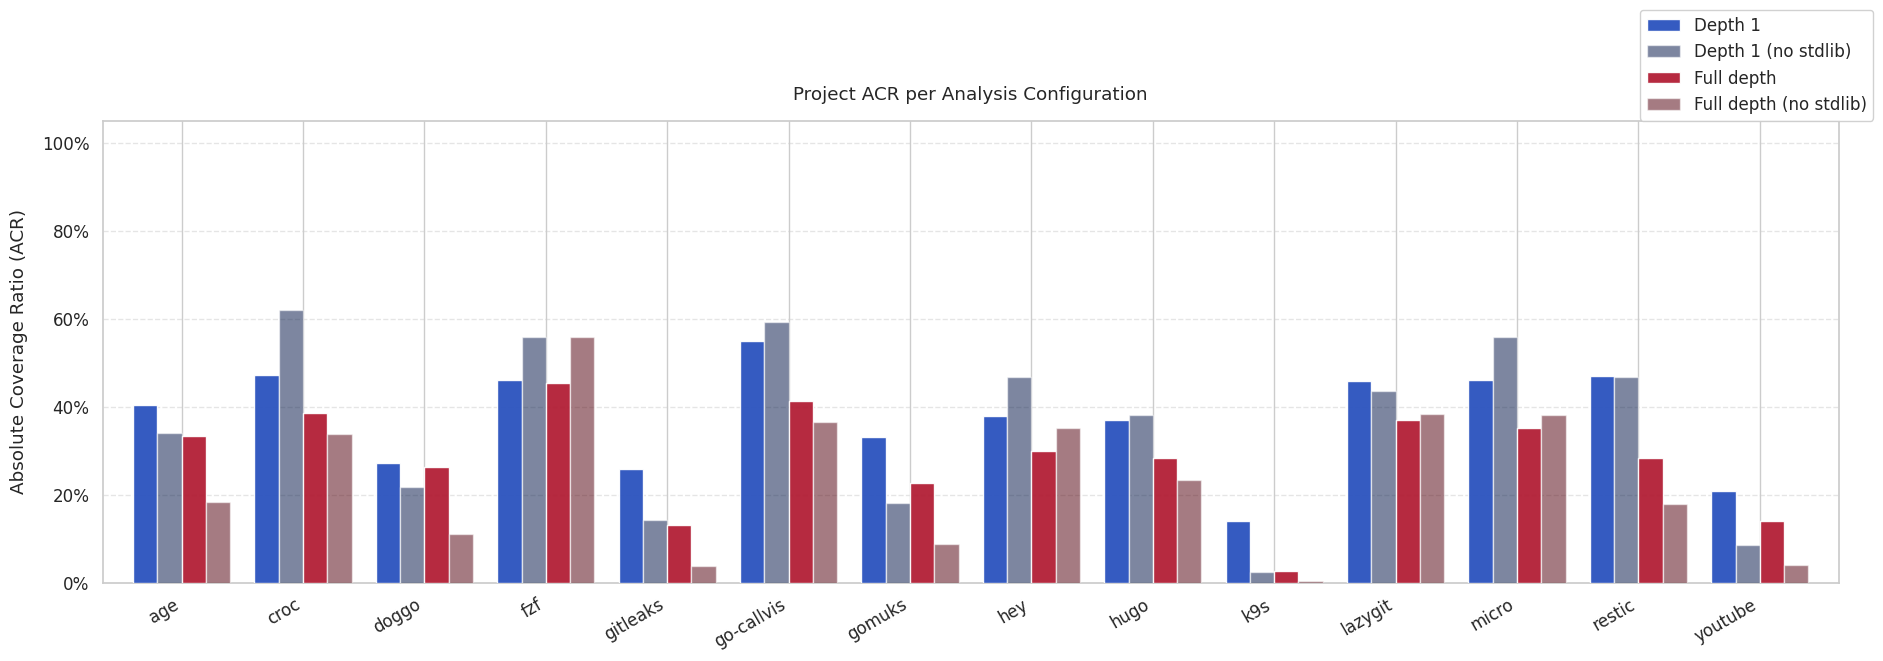

In [50]:
def plot_acr_grouped(proj_df: pd.DataFrame) -> None:
    pivot = (
        proj_df.pivot(index="project", columns="case", values="project_acr")
        .reindex(columns=CASE_ORDER)
        .sort_index()
    )

    render_grouped_distribution_plot(
        pivot_df=pivot,
        title="Project ACR per Analysis Configuration",
        ylabel="Absolute Coverage Ratio (ACR)",
        save_filename="project_acr_distribution.pdf",
        y_formatter=mticker.PercentFormatter(xmax=1),
        ylim=(0, 1.05),
        legend_loc="lower right",
        use_pandas_plot=True,
    )

plot_acr_grouped(GEN_PROJ_DF)

In [51]:
def generate_latex_acr_means_table(
    pkg_means: pd.DataFrame,
    case_order: list,
    case_labels: dict,
    landscape: bool = False,
    caption: str = "Mean package-level ACR per project and analysis configuration.",
    label: str = "tab:pkg_acr_means",
) -> str:
    """
    Generates a booktabs tabularx table from a pre-pivoted means DataFrame.
    Rows = projects, columns = cases, cells = mean ACR as percentage.
    Matches what the boxplot shows (mean of per-package ACR values).
    """
    available_cases = [c for c in case_order if c in pkg_means.columns]
    df = pkg_means[available_cases]

    latex = []
    env = r"\begin{sidewaystable}[htbp]" if landscape else r"\begin{table}[htbp]"
    latex.append(env)
    latex.append(r"  \centering")
    latex.append(f"  \\caption{{{caption}}}")
    latex.append(f"  \\label{{{label}}}")
    latex.append(r"  \small")

    n = len(available_cases)
    col_w = 0.70 / n
    col_def = f">{{\\hsize=0.30\\linewidth}}l " + "".join(
        f">{{\\hsize={col_w:.2f}\\linewidth\\centering\\arraybackslash}}X "
        for _ in range(n)
    )
    latex.append(f"  \\begin{{tabularx}}{{\\linewidth}}{{{col_def}}}")
    latex.append(r"    \toprule")

    headers = ["Project"] + [case_labels.get(c, c) for c in available_cases]
    latex.append("    " + " & ".join(f"\\textbf{{{h}}}" for h in headers) + r" \\")
    latex.append(r"    \midrule")

    for project, row in df.iterrows():
        escaped = str(project).replace("_", r"\_")
        cells = [escaped]
        for c in available_cases:
            val = row[c]
            cells.append(r"$\text{---}$" if pd.isna(val) else f"${val * 100:.1f}\\%$")
        latex.append("    " + " & ".join(cells) + r" \\")

    latex.append(r"    \bottomrule")
    latex.append(r"  \end{tabularx}")
    latex.append(r"\end{sidewaystable}" if landscape else r"\end{table}")

    result = "\n".join(latex)
    print(result)
    return result

# Usage
pkg_means = (
    PKG_DF[PKG_DF["func_total"] > 0]
    .groupby(["project", "case"])["acr"]
    .mean()
    .reset_index()
    .pivot(index="project", columns="case", values="acr")
    .reindex(columns=CASE_ORDER)
    .sort_index()
)


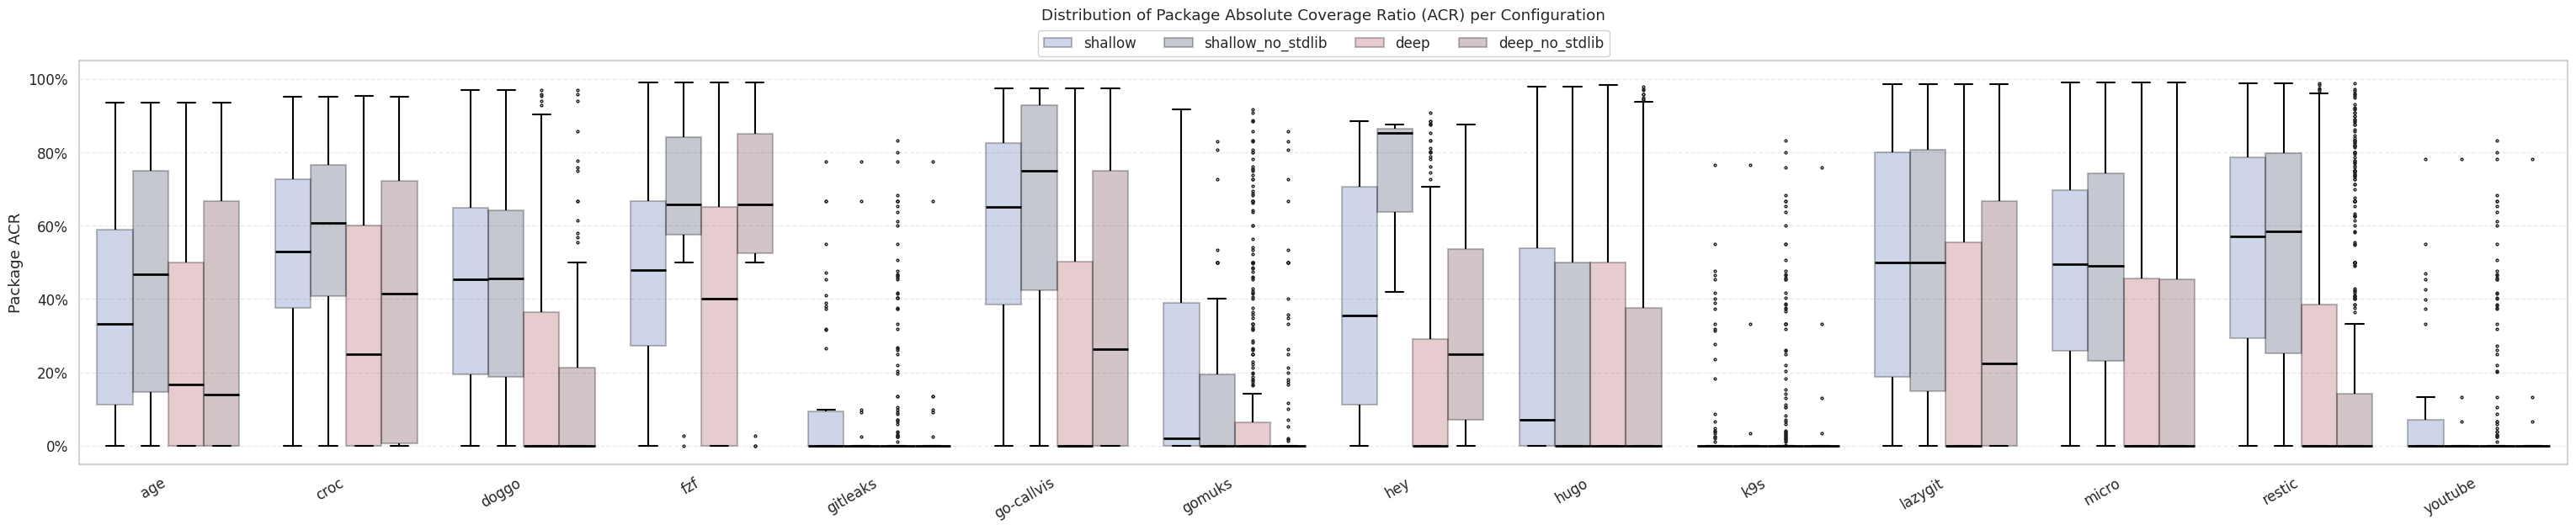

\begin{table}[htbp]
  \centering
  \caption{Mean package-level ACR per project and analysis configuration.}
  \label{tab:pkg_acr_means}
  \small
  \begin{tabularx}{\linewidth}{>{\hsize=0.30\linewidth}l >{\hsize=0.17\linewidth\centering\arraybackslash}X >{\hsize=0.17\linewidth\centering\arraybackslash}X >{\hsize=0.17\linewidth\centering\arraybackslash}X >{\hsize=0.17\linewidth\centering\arraybackslash}X }
    \toprule
    \textbf{Project} & \textbf{Depth 1} & \textbf{Depth 1 (no stdlib)} & \textbf{Full depth} & \textbf{Full depth (no stdlib)} \\
    \midrule
    age & $33.3\%$ & $46.9\%$ & $16.7\%$ & $13.9\%$ \\
    croc & $52.9\%$ & $60.8\%$ & $25.0\%$ & $41.4\%$ \\
    doggo & $45.3\%$ & $45.6\%$ & $0.0\%$ & $0.0\%$ \\
    fzf & $47.9\%$ & $65.8\%$ & $40.0\%$ & $65.8\%$ \\
    gitleaks & $0.0\%$ & $0.0\%$ & $0.0\%$ & $0.0\%$ \\
    go-callvis & $65.2\%$ & $75.0\%$ & $0.0\%$ & $26.3\%$ \\
    gomuks & $2.0\%$ & $0.0\%$ & $0.0\%$ & $0.0\%$ \\
    hey & $35.6\%$ & $85.3\%$ & $0.0\%$ & $2

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_package_acr_distribution(pkg_df: pd.DataFrame):
    """Renders a clean boxplot distribution showing package-level ACR

    across configurations grouped by project, with a horizontal layout legend up top.
    """
    plot_df = pkg_df[pkg_df["func_total"] > 0].copy()

    n_proj = plot_df["project"].nunique()
    # Boosted height slightly to 6.5 to give the top legend breathing room below the title
    fig, ax = plt.subplots(figsize=(max(12, n_proj * 2.2), 6.5))

    # Render the distribution curves
    sns.boxplot(
        data=plot_df,
        x="project",
        y="acr",
        hue="case",
        hue_order=CASE_ORDER,
        palette=CASE_COLORS,
        ax=ax,
        fliersize=2,
        linewidth=1.5,
        boxprops=dict(edgecolor="black", alpha=0.25),
        whiskerprops=dict(color="black", alpha=1.0),
        capprops=dict(color="black", alpha=1.0),
        medianprops=dict(color="black", linewidth=2.0, alpha=1.0),
    )

    # Styling & Typography
    # Increased title pad to 35 so it sits cleanly above the new top horizontal legend
    ax.set_title(
        "Distribution of Package Absolute Coverage Ratio (ACR) per Configuration",
        pad=35,
        fontweight="medium",
    )
    ax.set_ylabel("Package ACR")
    ax.set_xlabel("")
    ax.set_ylim(-0.05, 1.05)

    import matplotlib.ticker as mticker

    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

    ax.set_xticks(range(n_proj))
    ax.set_xticklabels(
        [t.get_text() for t in ax.get_xticklabels()], rotation=30, ha="right"
    )
    ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)

    # Fixed: Positioned centrally above the plot area in a flat horizontal line
    ax.legend(
        title="",  # Kept blank to keep the top bar clean and compact
        loc="lower center",
        bbox_to_anchor=(0.5, 1.01),
        ncol=len(CASE_ORDER),  # Spreads items horizontally
        framealpha=0.9,
        borderaxespad=0,
    )

    plt.tight_layout()
    plt.savefig("package_acr_distribution_boxplot.pdf", bbox_inches="tight")
    plt.show()


# Run the visualization setup
plot_package_acr_distribution(PKG_DF)


pkg_means = (
    PKG_DF[PKG_DF["func_total"] > 0]
    .groupby(["project", "case"])["acr"]
    .median()
    .reset_index()
    .pivot(index="project", columns="case", values="acr")
    .reindex(columns=CASE_ORDER)
    .sort_index()
)

generate_latex_acr_means_table(pkg_means, CASE_ORDER, CASE_LABELS)


print(PKG_DF[
    (PKG_DF["project"] == "age") & (PKG_DF["case"] == "deep") & (PKG_DF["func_total"] > 0)
]["acr"].mean())

# What the plot actually shows as the box centre
print(PKG_DF[
    (PKG_DF["project"] == "age") & (PKG_DF["case"] == "deep") & (PKG_DF["func_total"] > 0)
]["acr"].median())

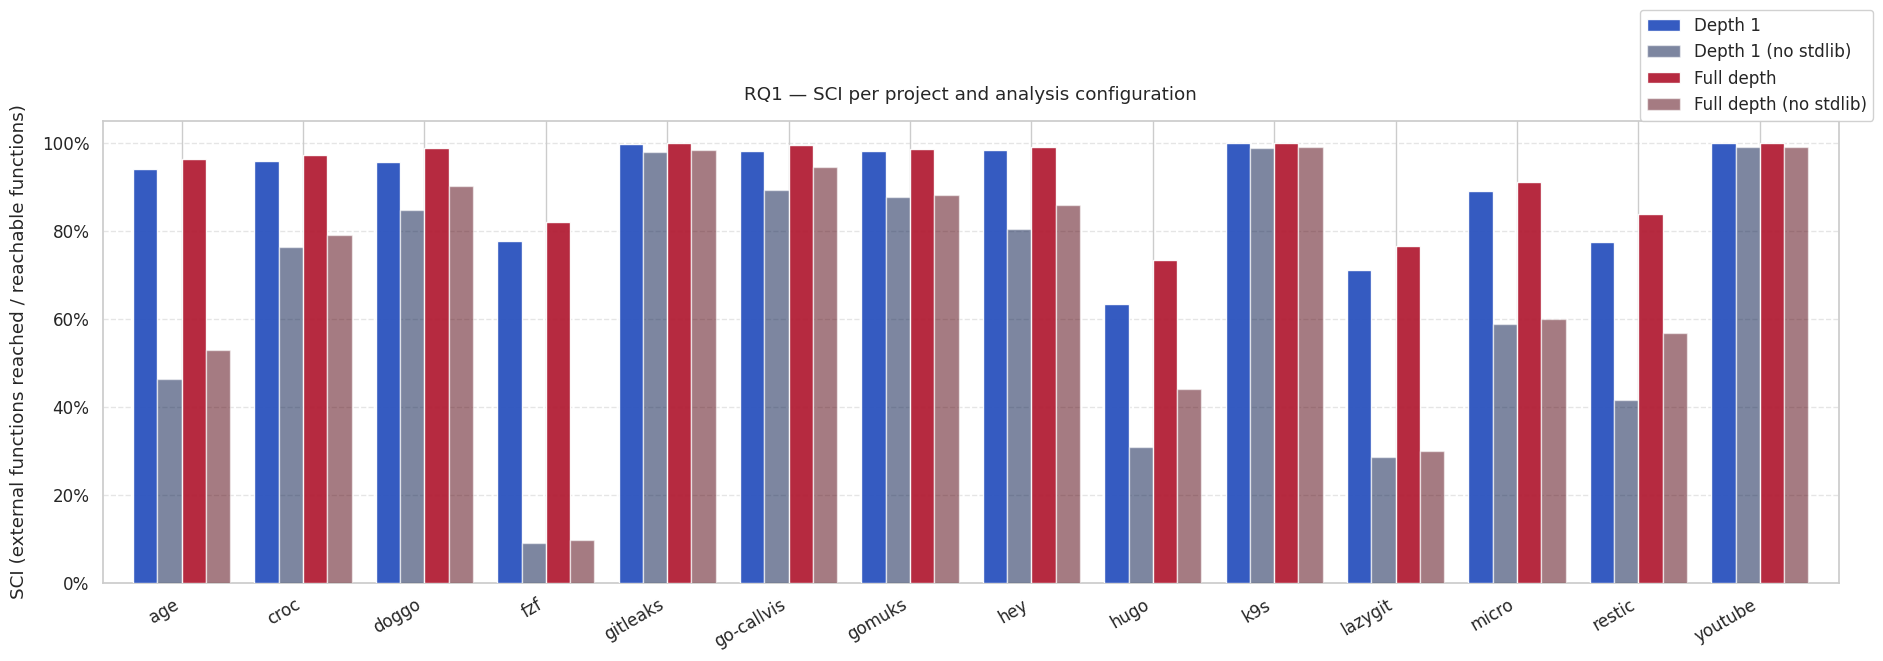

[LaTeX] Written to tab_rq1_sci.tex
\begin{table}[htbp]
  \centering
  \caption{Supply-Chain Index (SCI) per project and analysis configuration.}
  \label{tab:project_sci}
  \small
  \begin{tabularx}{\linewidth}{>{\hsize=0.30\linewidth}l >{\hsize=0.17\linewidth\centering\arraybackslash}X >{\hsize=0.17\linewidth\centering\arraybackslash}X >{\hsize=0.17\linewidth\centering\arraybackslash}X >{\hsize=0.17\linewidth\centering\arraybackslash}X }
    \toprule
    \textbf{Project} & \textbf{Depth 1} & \textbf{Depth 1 (no stdlib)} & \textbf{Full depth} & \textbf{Full depth (no stdlib)} \\
    \midrule
    age & $94.0\%$ & $46.3\%$ & \textbf{$96.3\%$} & $52.9\%$ \\
    croc & $95.8\%$ & $76.2\%$ & \textbf{$97.2\%$} & $79.0\%$ \\
    doggo & $95.6\%$ & $84.7\%$ & \textbf{$98.7\%$} & $90.0\%$ \\
    fzf & $77.7\%$ & $9.1\%$ & \textbf{$82.0\%$} & $9.8\%$ \\
    gitleaks & $99.8\%$ & $97.8\%$ & \textbf{$99.8\%$} & $98.4\%$ \\
    go-callvis & $98.2\%$ & $89.3\%$ & \textbf{$99.4\%$} & $94.4\%$ \\
    

'\\begin{table}[htbp]\n  \\centering\n  \\caption{Supply-Chain Index (SCI) per project and analysis configuration.}\n  \\label{tab:project_sci}\n  \\small\n  \\begin{tabularx}{\\linewidth}{>{\\hsize=0.30\\linewidth}l >{\\hsize=0.17\\linewidth\\centering\\arraybackslash}X >{\\hsize=0.17\\linewidth\\centering\\arraybackslash}X >{\\hsize=0.17\\linewidth\\centering\\arraybackslash}X >{\\hsize=0.17\\linewidth\\centering\\arraybackslash}X }\n    \\toprule\n    \\textbf{Project} & \\textbf{Depth 1} & \\textbf{Depth 1 (no stdlib)} & \\textbf{Full depth} & \\textbf{Full depth (no stdlib)} \\\\\n    \\midrule\n    age & $94.0\\%$ & $46.3\\%$ & \\textbf{$96.3\\%$} & $52.9\\%$ \\\\\n    croc & $95.8\\%$ & $76.2\\%$ & \\textbf{$97.2\\%$} & $79.0\\%$ \\\\\n    doggo & $95.6\\%$ & $84.7\\%$ & \\textbf{$98.7\\%$} & $90.0\\%$ \\\\\n    fzf & $77.7\\%$ & $9.1\\%$ & \\textbf{$82.0\\%$} & $9.8\\%$ \\\\\n    gitleaks & $99.8\\%$ & $97.8\\%$ & \\textbf{$99.8\\%$} & $98.4\\%$ \\\\\n    go-callvis & $98.2\\%$

In [53]:
def plot_sci_grouped(proj_df: pd.DataFrame) -> None:
    pivot = (
        proj_df.pivot(index="project", columns="case", values="sci")
        .reindex(columns=CASE_ORDER)
        .sort_index()
    )

    render_grouped_distribution_plot(
        pivot_df=pivot,
        title="RQ1 — SCI per project and analysis configuration",
        ylabel="SCI (external functions reached / reachable functions)",
        save_filename="rq1_sci.pdf",
        y_formatter=mticker.PercentFormatter(xmax=1),
        ylim=(0, 1.05),
        legend_loc="lower right",
        use_pandas_plot=True,
    )
    

plot_sci_grouped(PROJ_DF)

def generate_latex_sci_table(
    proj_df: pd.DataFrame,
    case_order: list,
    case_labels: dict,
    landscape: bool = False,
    caption: str = "Supply-Chain Index (SCI) per project and analysis configuration.",
    label: str = "tab:project_sci",
    filename: str | None = None,
) -> str:
    """
    Generates a booktabs tabularx LaTeX table of SCI values.
    Rows = projects, columns = cases, cells = SCI as percentage.
    Also appends a summary row with mean and median per configuration.
    """
    available_cases = [c for c in case_order if c in proj_df["case"].unique()]

    pivot = (
        proj_df.pivot(index="project", columns="case", values="sci")
        .reindex(columns=available_cases)
        .sort_index()
    )

    n = len(available_cases)
    col_w = 0.70 / n
    col_def = f">{{\\hsize=0.30\\linewidth}}l " + "".join(
        f">{{\\hsize={col_w:.2f}\\linewidth\\centering\\arraybackslash}}X "
        for _ in range(n)
    )

    latex = []
    latex.append(r"\begin{sidewaystable}[htbp]" if landscape else r"\begin{table}[htbp]")
    latex.append(r"  \centering")
    latex.append(f"  \\caption{{{caption}}}")
    latex.append(f"  \\label{{{label}}}")
    latex.append(r"  \small")
    latex.append(f"  \\begin{{tabularx}}{{\\linewidth}}{{{col_def}}}")
    latex.append(r"    \toprule")

    # Header
    headers = ["Project"] + [case_labels.get(c, c) for c in available_cases]
    latex.append("    " + " & ".join(f"\\textbf{{{h}}}" for h in headers) + r" \\")
    latex.append(r"    \midrule")

    # Per-project rows — bold the max SCI per row
    for project, row in pivot.iterrows():
        escaped = str(project).replace("_", r"\_")
        valid   = row.dropna()
        max_val = valid.max() if not valid.empty else None
        cells   = [escaped]
        for c in available_cases:
            val = row[c]
            if pd.isna(val):
                cells.append(r"$\text{---}$")
            else:
                formatted = f"${val * 100:.1f}\\%$"
                if max_val is not None and abs(val - max_val) < 1e-9:
                    formatted = f"\\textbf{{{formatted}}}"
                cells.append(formatted)
        latex.append("    " + " & ".join(cells) + r" \\")

    latex.append(r"    \bottomrule")
    latex.append(r"  \end{tabularx}")
    latex.append(r"\end{sidewaystable}" if landscape else r"\end{table}")

    result = "\n".join(latex)

    if filename:
        path = Path(filename) if filename.endswith(".tex") else Path(filename + ".tex")
        path.write_text(result, encoding="utf-8")
        print(f"[LaTeX] Written to {path}")

    print(result)
    return result


# Usage
generate_latex_sci_table(
    PROJ_DF,
    case_order  = CASE_ORDER,
    case_labels = CASE_LABELS,
    filename    = "tab_rq1_sci",
)

/tmp/ipykernel_6586/3314239842.py:40: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  0, plt.Rectangle((0, 0), 1, 1, color="green", alpha=0.25, edgecolor="gray")


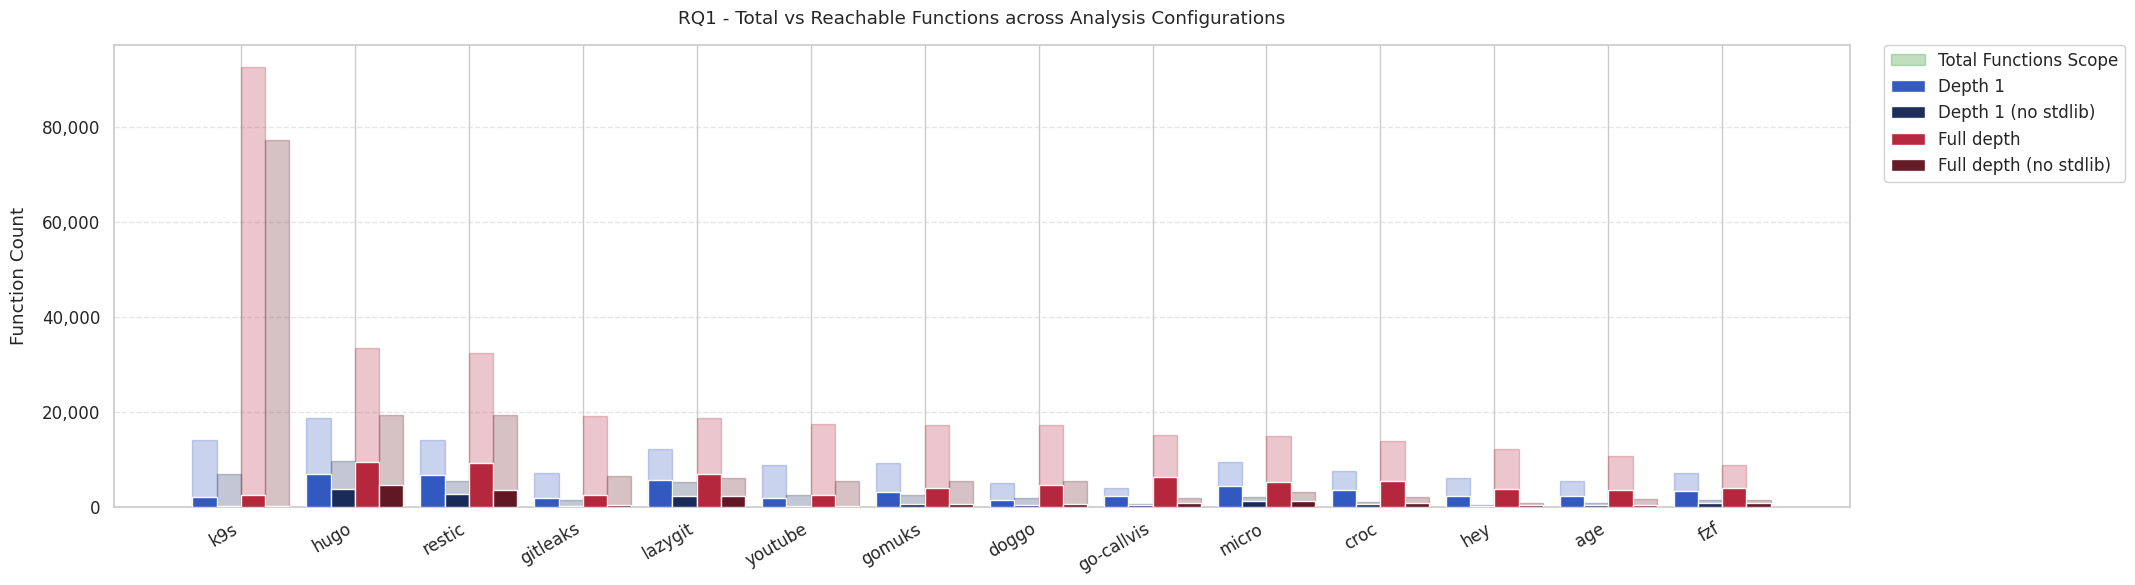

In [54]:
def plot_combined_total_vs_reached(proj_df: pd.DataFrame):
    pivot = proj_df.pivot(
        index="project", columns="case", values=["total_funcs", "reachable_funcs"]
    )
    pivot = pivot.reindex(
        pivot["total_funcs"].max(axis=1).sort_values(ascending=False).index
    )

    # Fixed: Added 'loc' and 'bbox' parameters to the function signature
    def draw_total_vs_reached_bars(ax, pivot_df, space_step, loc, bbox):
        n_cases = len(CASE_ORDER)
        base_pos = np.arange(len(pivot_df.index)) * space_step
        width = 0.85 / n_cases

        for i, case in enumerate(CASE_ORDER):
            pos = base_pos + (i - (n_cases - 1) / 2) * width
            color = CASE_COLORS[case]

            ax.bar(
                pos,
                pivot_df[("total_funcs", case)],
                width,
                color=color,
                alpha=0.25,
                edgecolor=color,
                zorder=2,
            )
            ax.bar(
                pos,
                pivot_df[("reachable_funcs", case)],
                width,
                color=color,
                alpha=0.95,
                label=CASE_LABELS[case],
                zorder=3,
            )

        handles, labels = ax.get_legend_handles_labels()
        handles.insert(
            0, plt.Rectangle((0, 0), 1, 1, color="green", alpha=0.25, edgecolor="gray")
        )
        labels.insert(0, "Total Functions Scope")
        
        # Fixed: Hooked up loc, bbox_to_anchor, and borderaxespad to respect the outer layout engine
        ax.legend(
            handles, 
            labels, 
            loc=loc, 
            bbox_to_anchor=bbox, 
            framealpha=0.9, 
            borderaxespad=0
        )

    render_grouped_distribution_plot(
        pivot_df=pivot,
        title="RQ1 - Total vs Reachable Functions across Analysis Configurations",
        ylabel="Function Count",
        save_filename="rq1_absolute_combined.pdf",
        y_formatter=mticker.StrMethodFormatter("{x:,.0f}"),
        custom_legend_setup=draw_total_vs_reached_bars,
        spacing=1.0,
    )

# This will now compile cleanly without argument alignment issues
plot_combined_total_vs_reached(PROJ_DF)

________
## Q4


In [55]:
def compute_q4_indirect_metrics(raw: dict) -> pd.DataFrame:
    """Extracts detailed indirect call and function propagation metrics."""
    rows = []
    for proj, cases in raw.items():
        for case, rep in cases.items():
            ind = rep.get("indirect", {})
            rows.append({
                "project": proj,
                "case": case,
                "staticCallSites"       : ind.get("staticCallSites"     , 0),
                "interfaceCallSites"    : ind.get("interfaceCallSites"  , 0),
                "funcVarCallSites"      : ind.get("funcVarCallSites"    , 0),
                "funcLiteralStores"     : ind.get("funcLiteralStores"   , 0),
                "funcNamedStores"       : ind.get("funcNamedStores"     , 0),
                "funcPropagations"      : ind.get("funcPropagations"    , 0),
                "funcInStructOrMap"     : ind.get("funcInStructOrMap"   , 0),
                "funcChans"             : ind.get("funcChans"           , 0),
                "goroutinesFuncChan"    : ind.get("goroutinesFuncChan"  , 0),
                "funcsSentToFuncChan"   : ind.get("funcsSentToFuncChan" , 0),
                "funcsReceivedForCall"  : ind.get("funcsReceivedForCall", 0)
            })
    return pd.DataFrame(rows)

INDIRECT_DF = compute_q4_indirect_metrics(RAW)
print(f"Indirect Metrics rows: {len(INDIRECT_DF)}")
INDIRECT_DF.head(10)

Indirect Metrics rows: 56


,project,case,staticCallSites,interfaceCallSites,funcVarCallSites,funcLiteralStores,funcNamedStores,funcPropagations,funcInStructOrMap,funcChans,goroutinesFuncChan,funcsSentToFuncChan,funcsReceivedForCall
0,age,shallow,10034,126,88,10,3,12,15,0,0,0,0
1,age,shallow_no_stdlib,1197,62,16,6,1,4,8,0,0,0,0
2,age,deep,14867,215,112,11,3,15,18,0,0,0,0
3,age,deep_no_stdlib,1312,62,16,6,1,4,8,0,0,0,0
4,croc,shallow,16072,526,191,17,75,112,126,0,0,0,0
5,croc,shallow_no_stdlib,3335,222,53,5,11,75,33,0,0,0,0
6,croc,deep,21587,786,275,23,75,122,137,0,0,0,0
7,croc,deep_no_stdlib,3609,225,53,5,11,75,33,0,0,0,0
8,doggo,shallow,6003,424,130,8,51,51,88,0,0,0,0
9,doggo,shallow_no_stdlib,2314,106,45,3,1,11,2,0,0,0,0


In [69]:
import pandas as pd

import pandas as pd

def generate_latex_indirect_counters_as_columns_table(
    indirect_df: pd.DataFrame,
    case_order: list,
    case_labels: dict,
    landscape: bool = True,
    caption: str = "Analysis Configurations and Indirect Metrics Profile per Project.",
    label: str = "tab:indirect_cols_metrics",
) -> str:
    """
    Generates a master booktabs tabularx table for ALL projects.
    Rows = Project -> 4 Analysis Configurations (Cases)
    Columns = The 11 Indirect Metrics / Counters
    """
    # Define the 11 metrics in their explicit horizontal column order
    metric_keys = [
        "staticCallSites",
        "interfaceCallSites",
        "funcVarCallSites",
        "funcLiteralStores",
        "funcNamedStores",
        "funcPropagations",
        "funcInStructOrMap",
        "funcChans",
        "goroutinesFuncChan",
        "funcsSentToFuncChan",
        "funcsReceivedForCall"
    ]

    # Abbreviated header labels to help 11 columns fit cleanly on a page
    metric_labels = {
        "staticCallSites": "Static",
        "interfaceCallSites": "Interface",
        "funcVarCallSites": "FuncVar",
        "funcLiteralStores": "LitStore",
        "funcNamedStores": "NamedStore",
        "funcPropagations": "Propag",
        "funcInStructOrMap": "StructMap",
        "funcChans": "Chan",
        "goroutinesFuncChan": "GoroChan",
        "funcsSentToFuncChan": "SentChan",
        "funcsReceivedForCall": "RecvCall"
    }

    # Filter to get valid configurations and unique sorted projects
    available_cases = [c for c in case_order if c in indirect_df["case"].unique()]
    unique_projects = sorted(indirect_df["project"].unique())

    latex = []
    env = r"\begin{sidewaystable}[htbp]" if landscape else r"\begin{table}[htbp]"
    latex.append(env)
    latex.append(r"  \centering")
    latex.append(f"  \\caption{{{caption}}}")
    latex.append(f"  \\label{{{label}}}")
    latex.append(r"  \scriptsize")  # Using scriptsize to safely accommodate 11 structural columns

    # Column Distribution:
    # 12% for Project string, 13% for Case label, remaining 75% split evenly among the 11 counters
    n_metrics = len(metric_keys)
    metric_w = 0.75 / n_metrics
    col_def = f">{{\\hsize=0.12\\linewidth}}l >{{\\hsize=0.13\\linewidth}}l " + "".join(
        f">{{\\hsize={metric_w:.3f}\\linewidth\\centering\\arraybackslash}}X "
        for _ in range(n_metrics)
    )
    
    latex.append(f"  \\begin{{tabularx}}{{\\linewidth}}{{{col_def}}}")
    latex.append(r"    \toprule")

    # Build Header Row
    headers = ["Project", "Configuration"] + [metric_labels.get(m, m) for m in metric_keys]
    latex.append("    " + " & ".join(f"\\textbf{{{h}}}" for h in headers) + r" \\")
    latex.append(r"    \midrule")

    # Loop through each project
    for p_idx, project in enumerate(unique_projects):
        escaped_project = str(project).replace("_", r"\_")
        df_proj = indirect_df[indirect_df["project"] == project]

        # Reindex cases to guarantee order consistency
        df_proj_ordered = df_proj.set_index("case").reindex(available_cases).reset_index()

        for c_idx, case_name in enumerate(available_cases):
            # Print the project name only on the first row of its configuration block
            project_cell = escaped_project if c_idx == 0 else ""
            case_cell = case_labels.get(case_name, case_name)
            
            cells = [project_cell, case_cell]
            
            # Extract row matching the current case configuration
            row_match = df_proj_ordered[df_proj_ordered["case"] == case_name]
            
            for metric_key in metric_keys:
                if row_match.empty or metric_key not in row_match.columns:
                    cells.append(r"$\text{---}$")
                else:
                    val = row_match[metric_key].values[0]
                    cells.append(r"$\text{---}$" if pd.isna(val) else f"{int(val):,}")
            
            latex.append("    " + " & ".join(cells) + r" \\")
        
        # Add visual horizontal line separating projects (skipping after the last entry)
        if p_idx < len(unique_projects) - 1:
            latex.append(r"    \cmidrule(lr){1-2}")

    # --- FIX APPLIED HERE ---
    latex.append(r"    \bottomrule")
    latex.append(r"  \end{tabularx}")
    latex.append(r"\end{sidewaystable}" if landscape else r"\end{table}")

    result = "\n".join(latex)
    print(result)
    return result
# --- Execution ---
master_columns_tex = generate_latex_indirect_counters_as_columns_table(
    indirect_df=INDIRECT_DF,
    case_order=CASE_ORDER,
    case_labels=CASE_LABELS,
    landscape=True
)

\begin{sidewaystable}[htbp]
  \centering
  \caption{Analysis Configurations and Indirect Metrics Profile per Project.}
  \label{tab:indirect_cols_metrics}
  \scriptsize
  \begin{tabularx}{\linewidth}{>{\hsize=0.12\linewidth}l >{\hsize=0.13\linewidth}l >{\hsize=0.068\linewidth\centering\arraybackslash}X >{\hsize=0.068\linewidth\centering\arraybackslash}X >{\hsize=0.068\linewidth\centering\arraybackslash}X >{\hsize=0.068\linewidth\centering\arraybackslash}X >{\hsize=0.068\linewidth\centering\arraybackslash}X >{\hsize=0.068\linewidth\centering\arraybackslash}X >{\hsize=0.068\linewidth\centering\arraybackslash}X >{\hsize=0.068\linewidth\centering\arraybackslash}X >{\hsize=0.068\linewidth\centering\arraybackslash}X >{\hsize=0.068\linewidth\centering\arraybackslash}X >{\hsize=0.068\linewidth\centering\arraybackslash}X }
    \toprule
    \textbf{Project} & \textbf{Configuration} & \textbf{Static} & \textbf{Interface} & \textbf{FuncVar} & \textbf{LitStore} & \textbf{NamedStore} & \textbf{Propa

In [70]:
def compute_all_signature_metrics(raw: dict) -> pd.DataFrame:
    """Extracts signature metrics for potential targets vs actual call sites across ALL cases."""
    rows = []
    for proj, cases in raw.items():
        for case, rep in cases.items():  # Iterate through all available cases
            sigs = rep.get("indirect", {}).get("signatureMetrics", {})
            for sig, metrics in sigs.items():
                rows.append(
                    {
                        "project": proj,
                        "case": case,  # Track which configuration this belongs to
                        "signature": sig,
                        "potentialTargets": metrics.get("potentialTargets", 0),
                        "actualCallSites": metrics.get("actualCallSites", 0),
                    }
                )
    return pd.DataFrame(rows)


# Process the entire dataset
ALL_SIG_DF = compute_all_signature_metrics(RAW)

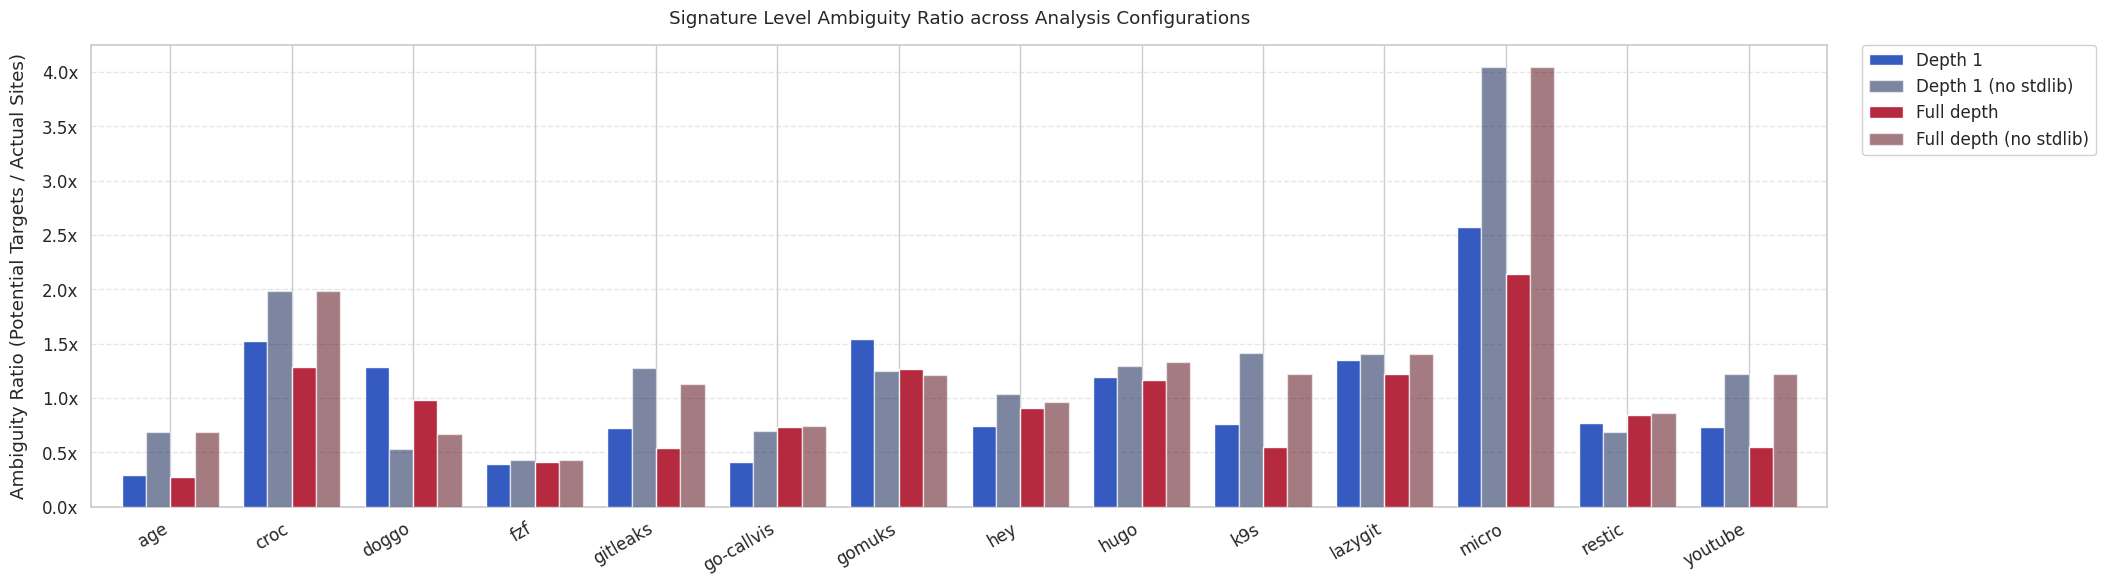

In [58]:
def plot_signature_ambiguity_all_cases(df: pd.DataFrame):
    """Aggregates signature metrics by project and case, then plots the

    resulting Ambiguity Ratio across all configurations with a top-centered legend.
    """
    # 1. Aggregate counts per project, per case
    grouped = (
        df.groupby(["project", "case"])[["potentialTargets", "actualCallSites"]]
        .sum()
        .reset_index()
    )

    # 2. Calculate the Ambiguity Ratio safely avoiding divide-by-zero warnings
    grouped["ambiguity_ratio"] = grouped["potentialTargets"] / grouped[
        "actualCallSites"
    ].replace(0, np.nan)

    # 3. Pivot data matrix so projects are rows and configurations are columns
    pivot_df = (
        grouped.pivot(index="project", columns="case", values="ambiguity_ratio")
        .reindex(columns=CASE_ORDER)
        .sort_index()
    )  # Keep sorting matches consistent with SCI/ACR bar layouts

    # 4. Hand off to the absolute-centered horizontal core engine
    render_grouped_distribution_plot(
        pivot_df=pivot_df,
        title="Signature Level Ambiguity Ratio across Analysis Configurations",
        ylabel="Ambiguity Ratio (Potential Targets / Actual Sites)",
        save_filename="rq4_signature_ambiguity_all_cases.pdf",
        y_formatter=mticker.FormatStrFormatter("%.1fx"),
        use_pandas_plot=True,
    )


# Execute the layout generator
plot_signature_ambiguity_all_cases(ALL_SIG_DF)

In [75]:
import numpy as np
import pandas as pd

def generate_latex_signature_ambiguity_table(
    sig_df: pd.DataFrame,
    case_order: list,
    case_labels: dict,
    landscape: bool = False,
    caption: str = "Signature-level ambiguity ratio across analysis configurations.",
    label: str = "tab:sig_ambiguity_ratios",
) -> str:
    """
    Generates a booktabs tabularx table from ALL_SIG_DF.
    Rows = projects, columns = cases, cells = ambiguity ratio formatted as a factor suffix (e.g., 1.5x).
    """
    # 1. Aggregate counts per project, per case matching your plotting script logic
    grouped = (
        sig_df.groupby(["project", "case"])[["potentialTargets", "actualCallSites"]]
        .sum()
        .reset_index()
    )

    # 2. Calculate the Ambiguity Ratio safely avoiding divide-by-zero errors
    grouped["ambiguity_ratio"] = grouped["potentialTargets"] / grouped[
        "actualCallSites"
    ].replace(0, np.nan)

    # 3. Pivot data matrix exactly like the plotting routine
    pivot_df = (
        grouped.pivot(index="project", columns="case", values="ambiguity_ratio")
        .reindex(columns=case_order)
        .sort_index()
    )

    available_cases = [c for c in case_order if c in pivot_df.columns]
    df = pivot_df[available_cases]

    latex = []
    env = r"\begin{sidewaystable}[htbp]" if landscape else r"\begin{table}[htbp]"
    latex.append(env)
    latex.append(r"  \centering")
    latex.append(f"  \\caption{{{caption}}}")
    latex.append(f"  \\label{{{label}}}")
    latex.append(r"  \small")

    n = len(available_cases)
    col_w = 0.70 / n
    col_def = f">{{\\hsize=0.30\\linewidth}}l " + "".join(
        f">{{\\hsize={col_w:.2f}\\linewidth\\centering\\arraybackslash}}X "
        for _ in range(n)
    )
    latex.append(f"  \\begin{{tabularx}}{{\\linewidth}}{{{col_def}}}")
    latex.append(r"    \toprule")

    headers = ["Project"] + [case_labels.get(c, c) for c in available_cases]
    latex.append("    " + " & ".join(f"\\textbf{{{h}}}" for h in headers) + r" \\")
    latex.append(r"    \midrule")

    for project, row in df.iterrows():
        escaped = str(project).replace("_", r"\_")
        cells = [escaped]
        for c in available_cases:
            val = row[c]
            cells.append(r"$\text{---}$" if pd.isna(val) else f"${val:.1f}\\text{{x}}$")
        latex.append("    " + " & ".join(cells) + r" \\")

    latex.append(r"    \bottomrule")
    latex.append(r"  \end{tabularx}")
    latex.append(r"\end{sidewaystable}" if landscape else r"\end{table}")

    result = "\n".join(latex)
    return result

print("--- SIGNATURE AMBIGUITY LATEX SOURCE ---")
ambiguity_tex = generate_latex_signature_ambiguity_table(
    sig_df=ALL_SIG_DF,
    case_order=CASE_ORDER,
    case_labels=CASE_LABELS
)
print(ambiguity_tex)

--- SIGNATURE AMBIGUITY LATEX SOURCE ---
\begin{table}[htbp]
  \centering
  \caption{Signature-level ambiguity ratio across analysis configurations.}
  \label{tab:sig_ambiguity_ratios}
  \small
  \begin{tabularx}{\linewidth}{>{\hsize=0.30\linewidth}l >{\hsize=0.17\linewidth\centering\arraybackslash}X >{\hsize=0.17\linewidth\centering\arraybackslash}X >{\hsize=0.17\linewidth\centering\arraybackslash}X >{\hsize=0.17\linewidth\centering\arraybackslash}X }
    \toprule
    \textbf{Project} & \textbf{Depth 1} & \textbf{Depth 1 (no stdlib)} & \textbf{Full depth} & \textbf{Full depth (no stdlib)} \\
    \midrule
    age & $0.3\text{x}$ & $0.7\text{x}$ & $0.3\text{x}$ & $0.7\text{x}$ \\
    croc & $1.5\text{x}$ & $2.0\text{x}$ & $1.3\text{x}$ & $2.0\text{x}$ \\
    doggo & $1.3\text{x}$ & $0.5\text{x}$ & $1.0\text{x}$ & $0.7\text{x}$ \\
    fzf & $0.4\text{x}$ & $0.4\text{x}$ & $0.4\text{x}$ & $0.4\text{x}$ \\
    gitleaks & $0.7\text{x}$ & $1.3\text{x}$ & $0.5\text{x}$ & $1.1\text{x}$ \\
    

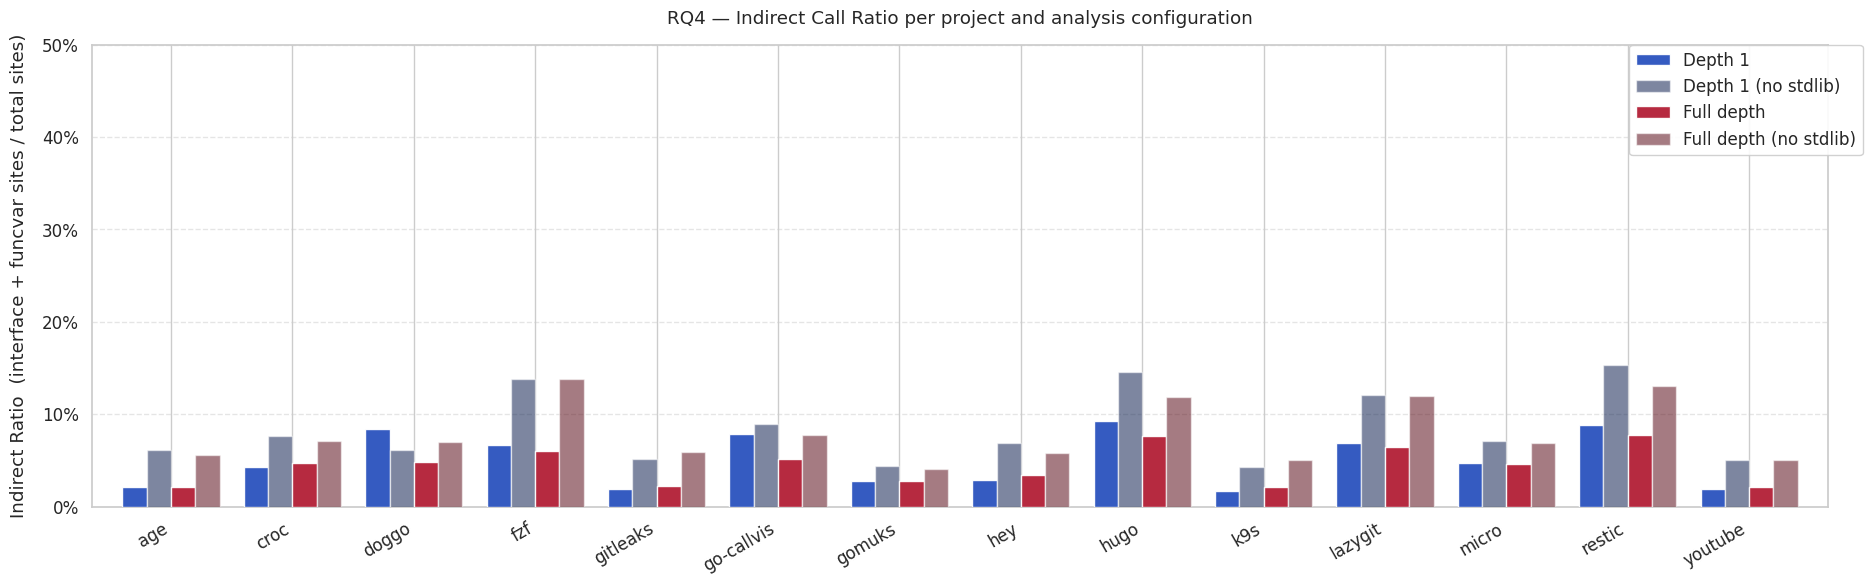

In [ ]:
def plot_indirect_ratio_grouped(proj_df: pd.DataFrame) -> None:
    pivot = (
        proj_df.pivot(index="project", columns="case", values="indirect_ratio")
        .reindex(columns=CASE_ORDER)
        .sort_index()
    )
    render_grouped_distribution_plot(
        pivot_df=pivot,
        title="Indirect Call Ratio per project and analysis configuration",
        ylabel="Indirect Ratio  (interface + funcvar sites / total sites)",
        save_filename="rq4_indirect_ratio.pdf",
        y_formatter=mticker.PercentFormatter(xmax=1),
        ylim=(0, 0.5),        # indirect ratios are usually low, adjust if needed
        legend_loc="upper right",
        use_pandas_plot=True,
    )

plot_indirect_ratio_grouped(PROJ_DF)

In [74]:
import pandas as pd

def generate_latex_indirect_ratio_table(
    proj_df: pd.DataFrame,
    case_order: list,
    case_labels: dict,
    landscape: bool = False,
    caption: str = "Indirect call ratio per project and analysis configuration.",
    label: str = "tab:indirect_ratio_means",
) -> str:
    """
    Generates a booktabs tabularx table from PROJ_DF for indirect ratios.
    Rows = projects, columns = cases, cells = indirect ratio as a formatted percentage.
    """
    # Pivot matches exactly how your plot_indirect_ratio_grouped processes the data matrix
    pivot = (
        proj_df.pivot(index="project", columns="case", values="indirect_ratio")
        .reindex(columns=case_order)
        .sort_index()
    )

    available_cases = [c for c in case_order if c in pivot.columns]
    df = pivot[available_cases]

    latex = []
    env = r"\begin{sidewaystable}[htbp]" if landscape else r"\begin{table}[htbp]"
    latex.append(env)
    latex.append(r"  \centering")
    latex.append(f"  \\caption{{{caption}}}")
    latex.append(f"  \\label{{{label}}}")
    latex.append(r"  \small")

    n = len(available_cases)
    col_w = 0.70 / n
    col_def = f">{{\\hsize=0.30\\linewidth}}l " + "".join(
        f">{{\\hsize={col_w:.2f}\\linewidth\\centering\\arraybackslash}}X "
        for _ in range(n)
    )
    latex.append(f"  \\begin{{tabularx}}{{\\linewidth}}{{{col_def}}}")
    latex.append(r"    \toprule")

    headers = ["Project"] + [case_labels.get(c, c) for c in available_cases]
    latex.append("    " + " & ".join(f"\\textbf{{{h}}}" for h in headers) + r" \\")
    latex.append(r"    \midrule")

    for project, row in df.iterrows():
        escaped = str(project).replace("_", r"\_")
        cells = [escaped]
        for c in available_cases:
            val = row[c]
            cells.append(r"$\text{---}$" if pd.isna(val) else f"${val * 100:.1f}\\%$")
        latex.append("    " + " & ".join(cells) + r" \\")

    latex.append(r"    \bottomrule")
    latex.append(r"  \end{tabularx}")
    latex.append(r"\end{sidewaystable}" if landscape else r"\end{table}")

    result = "\n".join(latex)
    return result


print("--- INDIRECT RATIO LATEX SOURCE ---")
indirect_ratio_tex = generate_latex_indirect_ratio_table(
    proj_df=PROJ_DF,
    case_order=CASE_ORDER,
    case_labels=CASE_LABELS
)
print(indirect_ratio_tex)

--- INDIRECT RATIO LATEX SOURCE ---
\begin{table}[htbp]
  \centering
  \caption{Indirect call ratio per project and analysis configuration.}
  \label{tab:indirect_ratio_means}
  \small
  \begin{tabularx}{\linewidth}{>{\hsize=0.30\linewidth}l >{\hsize=0.17\linewidth\centering\arraybackslash}X >{\hsize=0.17\linewidth\centering\arraybackslash}X >{\hsize=0.17\linewidth\centering\arraybackslash}X >{\hsize=0.17\linewidth\centering\arraybackslash}X }
    \toprule
    \textbf{Project} & \textbf{Depth 1} & \textbf{Depth 1 (no stdlib)} & \textbf{Full depth} & \textbf{Full depth (no stdlib)} \\
    \midrule
    age & $2.1\%$ & $6.1\%$ & $2.2\%$ & $5.6\%$ \\
    croc & $4.3\%$ & $7.6\%$ & $4.7\%$ & $7.2\%$ \\
    doggo & $8.4\%$ & $6.1\%$ & $4.9\%$ & $7.0\%$ \\
    fzf & $6.6\%$ & $13.8\%$ & $6.1\%$ & $13.8\%$ \\
    gitleaks & $1.9\%$ & $5.2\%$ & $2.2\%$ & $5.9\%$ \\
    go-callvis & $7.8\%$ & $9.0\%$ & $5.2\%$ & $7.7\%$ \\
    gomuks & $2.8\%$ & $4.4\%$ & $2.8\%$ & $4.0\%$ \\
    hey & $2.8\%$ &

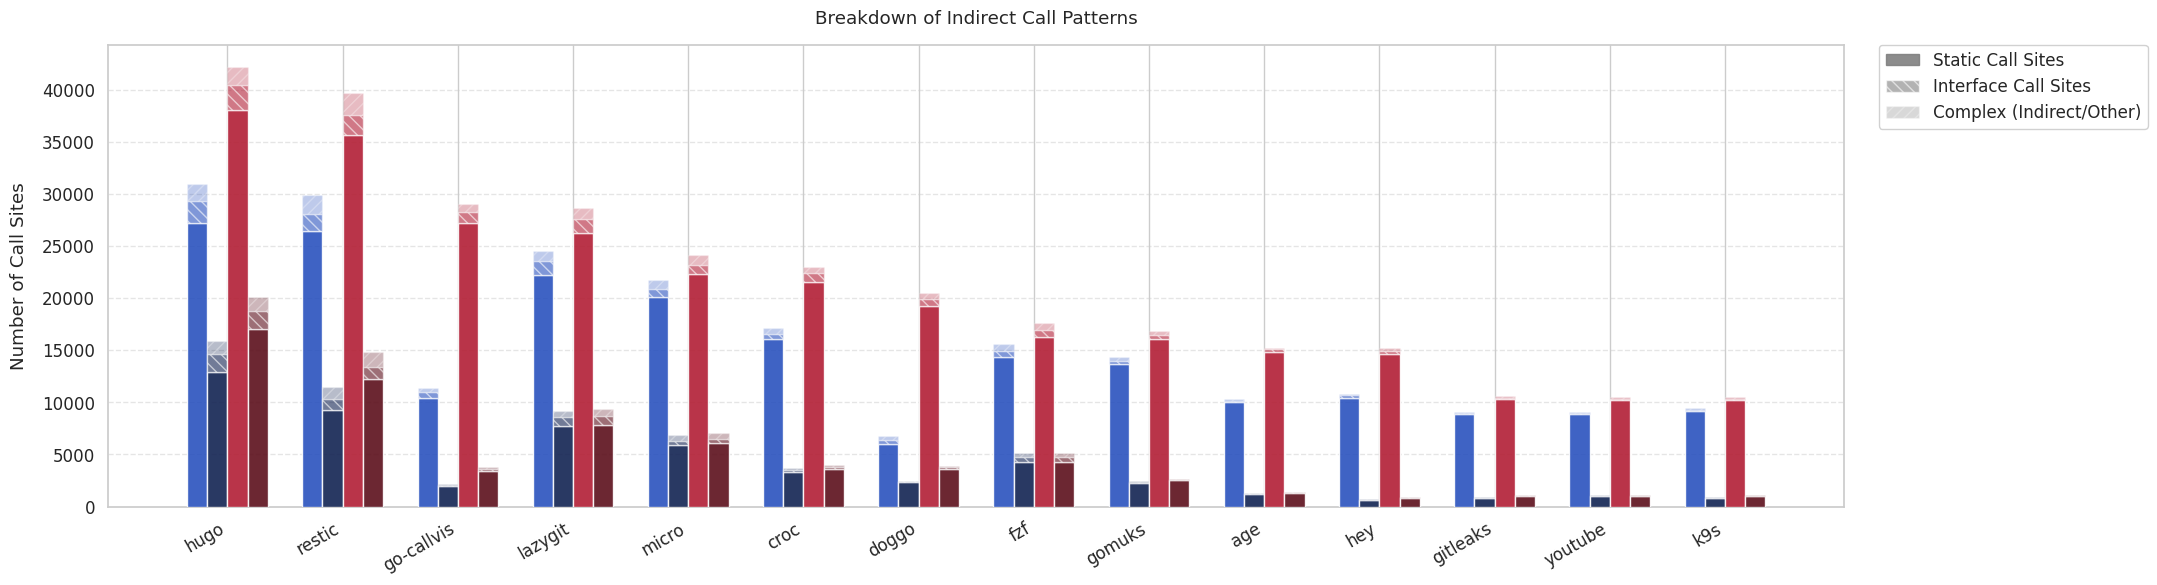

In [76]:
def plot_indirect_comparison_grouped(df: pd.DataFrame, spacing=1.5):
    # 1. Data Transformation Layer
    df = df.copy()
    cols_to_sum = [
        "funcVarCallSites",
        "funcLiteralStores",
        "funcNamedStores",
        "funcPropagations",
        "funcInStructOrMap",
        "funcChans",
        "goroutinesFuncChan",
        "funcsSentToFuncChan",
        "funcsReceivedForCall",
    ]
    df["Static"], df["Interface"], df["Complex"] = (
        df["staticCallSites"],
        df["interfaceCallSites"],
        df[cols_to_sum].sum(axis=1),
    )

    pivot = df.pivot(
        index="project", columns="case", values=["Static", "Interface", "Complex"]
    )
    sort_order = pivot[("Static", "deep")] + pivot[("Interface", "deep")]
    pivot = pivot.reindex(sort_order.sort_values(ascending=False).index)

    # 2. Spliced Stacked-Bar Logic Block
    # Fixed: Updated function signature to accept loc and bbox from the unified engine
    def draw_stacked_bars(ax, pivot_df, space_step, loc, bbox):
        n_cases = len(CASE_ORDER)
        base_pos = np.arange(len(pivot_df.index)) * space_step
        width = (space_step * 0.7) / n_cases

        for i, case in enumerate(CASE_ORDER):
            pos = base_pos + (i - (n_cases - 1) / 2) * width
            c = CASE_COLORS[case]

            s, j, cp = (
                pivot_df[("Static", case)],
                pivot_df[("Interface", case)],
                pivot_df[("Complex", case)],
            )
            ax.bar(pos, s, width, color=c, alpha=0.9, zorder=3)
            ax.bar(
                pos, j, width, bottom=s, color=c, alpha=0.6, hatch="\\\\\\", zorder=3
            )
            ax.bar(
                pos, cp, width, bottom=s + j, color=c, alpha=0.3, hatch="///", zorder=3
            )

        from matplotlib.patches import Patch

        # Fixed: Tied parameters to outer layout engine constants
        ax.legend(
            [
                Patch(color="gray", alpha=0.9),
                Patch(facecolor="gray", alpha=0.6, hatch="\\\\\\"),
                Patch(facecolor="gray", alpha=0.3, hatch="///"),
            ],
            ["Static Call Sites", "Interface Call Sites", "Complex (Indirect/Other)"],
            loc=loc,
            bbox_to_anchor=bbox,
            framealpha=0.9,
            borderaxespad=0,
        )

    # 3. Dispatched Plotting Configuration
    render_grouped_distribution_plot(
        pivot_df=pivot,
        title="Breakdown of Indirect Call Patterns",
        ylabel="Number of Call Sites",
        save_filename="rq4_grouped_comparison_compact.pdf",
        custom_legend_setup=draw_stacked_bars,
        spacing=spacing,
    )


# Running this now will resolve perfectly!
plot_indirect_comparison_grouped(INDIRECT_DF, spacing=1.5)

## RQ3

Utilization rows (shared pkgs only): 1,842


,n_pkgs,mean_U,median_U,std_U
case,,,,
shallow,119,0.5047,0.5177,0.3041
shallow_no_stdlib,43,0.4187,0.4087,0.3040
deep,971,0.2309,0.0286,0.3083
deep_no_stdlib,709,0.1545,0.0000,0.2600


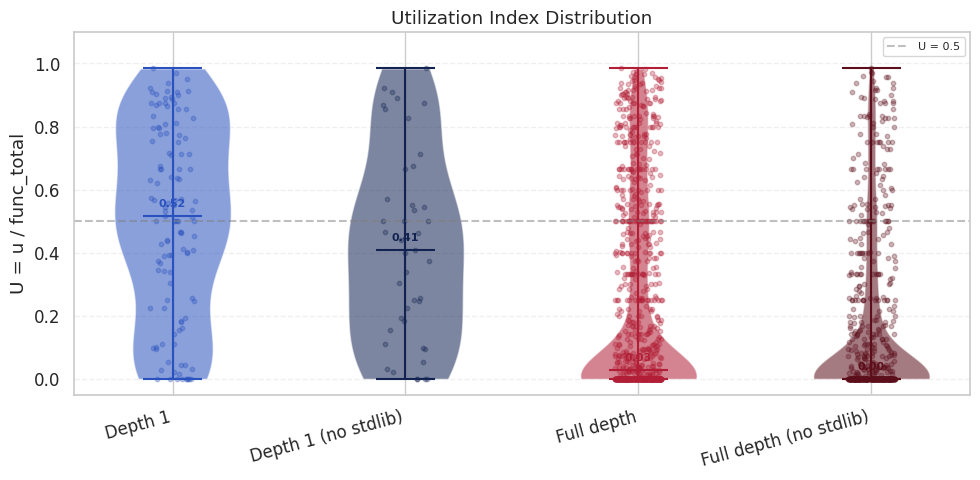


── Top 10 [Full depth (no stdlib)] ──
                                pkg_path  n_deps  func_total   u  utilization
       github.com/olekukonko/tablewriter       4         190 187     0.984211
         github.com/goccy/go-yaml/parser       2         113 110     0.973451
        github.com/goccy/go-yaml/scanner       2         101  98     0.970297
          golang.org/x/tools/go/packages       2          73  70     0.958904
        github.com/mitchellh/reflectwalk       3          24  23     0.958333
         github.com/pelletier/go-toml/v2       4         118 113     0.957627
github.com/pelletier/go-toml/v2/unstable       4          74  70     0.945946
                  github.com/rivo/uniseg       7          32  30     0.937500
         github.com/gobwas/glob/compiler       2          16  15     0.937500
     golang.org/x/tools/internal/aliases       2          13  12     0.923077

── Bottom 10 [Full depth (no stdlib)] ──
                                          pkg_path  n_deps  f

In [60]:
def compute_utilization_index(raw: dict) -> pd.DataFrame:
    rows = [
        {
            "project":    project,
            "case":       case,
            "pkg_path":   pkg_path,
            "func_total": pkg.get("functionCount", 0),
            "unused":     set(pkg.get("unusedFunctions", [])),
            "is_stdlib":  pkg.get("isStdlib", False),
        }
        for project, cases   in raw.items()
        for case,    data    in cases.items()
        for pkg_path, pkg    in data["packages"].items()
        if  pkg.get("depth", 0) > 0
    ]
 
    return (
        pd.DataFrame(rows)
        .groupby(["pkg_path", "case"], sort=False)
        .agg(
            n_deps     = ("project",   "nunique"),
            func_total = ("func_total","first"),
            never_used = ("unused",    lambda x: set.intersection(*x)),
            is_stdlib  = ("is_stdlib", "first"),
        )
        .assign(
            u           = lambda df: df["func_total"] - df["never_used"].str.len(),
            utilization = lambda df: df["u"] / df["func_total"].replace(0, np.nan),
        )
        .reset_index()
        .sort_values(["case", "utilization"], ascending=[True, False])
    )
 
 
# ================================================================================================
 
def plot_utilization_distribution(util_df: pd.DataFrame) -> None:
    plot_df = util_df.dropna(subset=["utilization"])
    cases   = [c for c in CASE_ORDER if c in plot_df["case"].unique()]
 
    fig, ax = plt.subplots(figsize=(10, 5))
 
    for pos, case in enumerate(cases):
        data  = plot_df.loc[plot_df["case"] == case, "utilization"]
        color = CASE_COLORS[case]
 
        vp = ax.violinplot(data, positions=[pos], showmedians=True)
        for part in vp["bodies"]:
            part.set_facecolor(color)
            part.set_alpha(0.55)
        for key in ("cmedians", "cmins", "cmaxes", "cbars"):
            vp[key].set_edgecolor(color)
            vp[key].set_linewidth(1.5)
 
        jitter = np.random.uniform(-0.1, 0.1, len(data))
        ax.scatter(pos + jitter, data, color=color, alpha=0.3, s=10)
        ax.text(pos, data.median() + 0.03, f"{data.median():.2f}",
                ha="center", fontweight="bold", color=color, fontsize=8)
 
    ax.set_xticks(range(len(cases)))
    ax.set_xticklabels([CASE_LABELS.get(c, c) for c in cases], rotation=15, ha="right")
    ax.set(title="Utilization Index Distribution", ylim=(-0.05, 1.1),
           ylabel="U = u / func_total")
    ax.axhline(0.5, color="grey", linestyle="--", alpha=0.5, label="U = 0.5")
    ax.legend(fontsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.savefig("utilization_index_distribution.pdf", bbox_inches="tight")
    plt.show()
 
 
# ================================================================================================
 
def print_top_bottom(util_df: pd.DataFrame, case: str, n: int = 10) -> None:
    sub = (
        util_df[(util_df["case"] == case) & (util_df["n_deps"] > 1)]
        .dropna(subset=["utilization"])
        .sort_values("utilization", ascending=False)
        [["pkg_path", "n_deps", "func_total", "u", "utilization"]]
    )
    for label, df in [("Top", sub.head(n)), ("Bottom", sub.tail(n).iloc[::-1])]:
        print(f"\n── {label} {n} [{CASE_LABELS[case]}] ──")
        print(df.to_string(index=False))
 


# ================================================================================================
UTIL_DF = compute_utilization_index(RAW)
UTIL_DF_SHARED = UTIL_DF[UTIL_DF["n_deps"] > 1].copy()
 
print(f"Utilization rows (shared pkgs only): {len(UTIL_DF_SHARED):,}")
display(
    UTIL_DF_SHARED.groupby("case")["utilization"]
    .agg(["count", "mean", "median", "std"])
    .reindex(CASE_ORDER)
    .rename(columns={"count": "n_pkgs", "mean": "mean_U", "median": "median_U", "std": "std_U"})
    .round(4)
)
 
plot_utilization_distribution(UTIL_DF_SHARED)

for case in ["deep_no_stdlib", "shallow_no_stdlib"]:
    print_top_bottom(UTIL_DF_SHARED, case)


In [61]:
def generate_latex_ui_summary_table(
    util_df: pd.DataFrame,
    case_order: list,
    case_labels: dict,
    caption: str = "Utilisation Index (UI) distribution summary across analysis configurations.",
    label: str = "tab:ui_summary",
    filename: str | None = None,
) -> str:
    """
    LaTeX table of count / mean / median / std of UI per case.
    Matches the display() summary shown in the notebook.
    """
    summary = (
        util_df.groupby("case")["utilization"]
        .agg(["count", "mean", "median", "std"])
        .reindex(case_order)
        .rename(columns={"count": "n\_pkgs", "mean": "Mean UI", "median": "Median UI", "std": "Std UI"})
    )

    latex = []
    latex.append(r"\begin{table}[htbp]")
    latex.append(r"  \centering")
    latex.append(f"  \\caption{{{caption}}}")
    latex.append(f"  \\label{{{label}}}")
    latex.append(r"  \small")
    latex.append(r"  \begin{tabularx}{\linewidth}{>{\hsize=0.35\linewidth}l >{\hsize=0.15\linewidth\centering\arraybackslash}X >{\hsize=0.17\linewidth\centering\arraybackslash}X >{\hsize=0.17\linewidth\centering\arraybackslash}X >{\hsize=0.16\linewidth\centering\arraybackslash}X}")
    latex.append(r"    \toprule")
    latex.append(r"    \textbf{Configuration} & \textbf{$n$ pkgs} & \textbf{Mean UI} & \textbf{Median UI} & \textbf{Std UI} \\")
    latex.append(r"    \midrule")

    for case in case_order:
        if case not in summary.index:
            continue
        row   = summary.loc[case]
        label_str = case_labels.get(case, case).replace("_", r"\_")
        latex.append(
            f"    {label_str} & "
            f"${int(row['n\\_pkgs']):,}$ & "
            f"${row['Mean UI']:.2f}$ & "
            f"${row['Median UI']:.2f}$ & "
            f"${row['Std UI']:.2f}$ \\\\"
        )

    latex.append(r"    \bottomrule")
    latex.append(r"  \end{tabularx}")
    latex.append(r"\end{table}")

    result = "\n".join(latex)

    if filename:
        path = Path(filename) if filename.endswith(".tex") else Path(filename + ".tex")
        path.write_text(result, encoding="utf-8")
        print(f"[LaTeX] Written to {path}")

    print(result)
    return result

# Usage
generate_latex_ui_summary_table(
    UTIL_DF,
    case_order  = CASE_ORDER,
    case_labels = CASE_LABELS,
    filename    = "tab_ui_summary",
)

[LaTeX] Written to tab_ui_summary.tex
\begin{table}[htbp]
  \centering
  \caption{Utilisation Index (UI) distribution summary across analysis configurations.}
  \label{tab:ui_summary}
  \small
  \begin{tabularx}{\linewidth}{>{\hsize=0.35\linewidth}l >{\hsize=0.15\linewidth\centering\arraybackslash}X >{\hsize=0.17\linewidth\centering\arraybackslash}X >{\hsize=0.17\linewidth\centering\arraybackslash}X >{\hsize=0.16\linewidth\centering\arraybackslash}X}
    \toprule
    \textbf{Configuration} & \textbf{$n$ pkgs} & \textbf{Mean UI} & \textbf{Median UI} & \textbf{Std UI} \\
    \midrule
    Depth 1 & $478$ & $0.29$ & $0.14$ & $0.32$ \\
    Depth 1 (no stdlib) & $373$ & $0.23$ & $0.08$ & $0.29$ \\
    Full depth & $3,157$ & $0.10$ & $0.00$ & $0.23$ \\
    Full depth (no stdlib) & $2,884$ & $0.07$ & $0.00$ & $0.19$ \\
    \bottomrule
  \end{tabularx}
\end{table}


<>:17: SyntaxWarning: invalid escape sequence '\_'
<>:17: SyntaxWarning: invalid escape sequence '\_'
/tmp/ipykernel_6586/2202652000.py:17: SyntaxWarning: invalid escape sequence '\_'
  .rename(columns={"count": "n\_pkgs", "mean": "Mean UI", "median": "Median UI", "std": "Std UI"})


'\\begin{table}[htbp]\n  \\centering\n  \\caption{Utilisation Index (UI) distribution summary across analysis configurations.}\n  \\label{tab:ui_summary}\n  \\small\n  \\begin{tabularx}{\\linewidth}{>{\\hsize=0.35\\linewidth}l >{\\hsize=0.15\\linewidth\\centering\\arraybackslash}X >{\\hsize=0.17\\linewidth\\centering\\arraybackslash}X >{\\hsize=0.17\\linewidth\\centering\\arraybackslash}X >{\\hsize=0.16\\linewidth\\centering\\arraybackslash}X}\n    \\toprule\n    \\textbf{Configuration} & \\textbf{$n$ pkgs} & \\textbf{Mean UI} & \\textbf{Median UI} & \\textbf{Std UI} \\\\\n    \\midrule\n    Depth 1 & $478$ & $0.29$ & $0.14$ & $0.32$ \\\\\n    Depth 1 (no stdlib) & $373$ & $0.23$ & $0.08$ & $0.29$ \\\\\n    Full depth & $3,157$ & $0.10$ & $0.00$ & $0.23$ \\\\\n    Full depth (no stdlib) & $2,884$ & $0.07$ & $0.00$ & $0.19$ \\\\\n    \\bottomrule\n  \\end{tabularx}\n\\end{table}'